<a href="https://colab.research.google.com/github/montidas663/uniprot_sprot_fasta/blob/main/uniprot_sprot_fasta.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
!pip install biopython

from Bio import SeqIO

MAX_SEQUENCES = 100000
sequences = []
for record in SeqIO.parse("uniprot_sprot.fasta", "fasta"):
    sequences.append(str(record.seq))
    # Check if we have reached our limit
    if len(sequences) >= MAX_SEQUENCES:
        break

print(f"Loaded {len(sequences)} sequences.")

Loaded 100000 sequences.


In [4]:
import numpy as np

# 1. Define the vocabulary
# The 20 standard amino acids
amino_acids = "ACDEFGHIKLMNPQRSTVWY"

# Map characters to unique integers, leaving 0-3 for special tokens
char_to_int = {char: idx + 4 for idx, char in enumerate(amino_acids)}
char_to_int["<PAD>"] = 0
char_to_int["<UNK>"] = 1   # For rare/ambiguous amino acids like X, B, Z
char_to_int["<START>"] = 2
char_to_int["<END>"] = 3

# Reverse mapping (useful later for decoding the autoencoder's output back to text)
int_to_char = {v: k for k, v in char_to_int.items()}

# 2. Process, truncate, and pad the sequences
MAX_LEN = 512  # Standard length constraint for protein models
processed_data = []

for seq in sequences:
    # Truncate sequence if it's longer than MAX_LEN (minus 2 slots for START/END tokens)
    truncated_seq = seq[:MAX_LEN - 2]

    # Convert characters to integers (defaults to <UNK> if character isn't standard)
    tokenized = [char_to_int["<START>"]] + [char_to_int.get(aa, 1) for aa in truncated_seq] + [char_to_int["<END>"]]

    # Pad with 0s if the sequence is shorter than MAX_LEN
    if len(tokenized) < MAX_LEN:
        tokenized += [char_to_int["<PAD>"]] * (MAX_LEN - len(tokenized))

    processed_data.append(tokenized)

# 3. Convert to a final NumPy array
X = np.array(processed_data)

print(f"Tokenization complete!")
print(f"Your input tensor shape is: {X.shape}")
print(f"Example of first sequence as integers:\n{X[0][:30]}...")

Tokenization complete!
Your input tensor shape is: (100000, 512)
Example of first sequence as integers:
[ 2 14  4  8 19  4  7  6 21 13 12  7 23  6 18 18 18 18 14  7  4 13 13 13
 19 13 23 23 16 15]...


In [5]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

# 1. Setup GPU if available, otherwise default to CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# 2. Convert our NumPy array into PyTorch Tensors and create a DataLoader
X_tensor = torch.tensor(X, dtype=torch.long)
dataset = TensorDataset(X_tensor, X_tensor) # Input and Target are identical in an autoencoder
dataloader = DataLoader(dataset, batch_size=10000, shuffle=True)

# 3. Define the Autoencoder Architecture
class ProteinAutoencoder(nn.Module):
    def __init__(self, vocab_size=24, seq_len=512, embedding_dim=16, latent_dim=64):
        super(ProteinAutoencoder, self).__init__()
        self.seq_len = seq_len
        self.vocab_size = vocab_size

        # Embedding layer maps integers to continuous vectors
        self.embedding = nn.Embedding(vocab_size, embedding_dim)

        # Flattened dimensions: 512 positions * 16 values per position = 8192
        flat_dim = seq_len * embedding_dim

        # Encoder: Compress down to latent space
        self.encoder = nn.Sequential(
            nn.Linear(flat_dim, 512),
            nn.ReLU(),
            nn.Linear(512, latent_dim) # The "bottleneck" representation
        )

        # Decoder: Decompress back to original shape
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 512),
            nn.ReLU(),
            nn.Linear(512, seq_len * vocab_size)
        )

    def forward(self, x):
        batch_size = x.size(0)

        # 1. Embed and flatten
        x = self.embedding(x) # Shape: (batch_size, 512, 16)
        x = x.view(batch_size, -1) # Shape: (batch_size, 8192)

        # 2. Encode to bottleneck
        latent = self.encoder(x) # Shape: (batch_size, latent_dim)

        # 3. Decode to raw scores (logits) for each amino acid
        reconstruction = self.decoder(latent) # Shape: (batch_size, 512 * 24)

        # Reshape to (batch_size, vocab_size, seq_len) required by PyTorch CrossEntropyLoss
        reconstruction = reconstruction.view(batch_size, self.vocab_size, self.seq_len)

        return reconstruction

# Initialize model
model = ProteinAutoencoder().to(device)

# 4. Loss Function and Optimizer
# Pro-Tip: ignore_index=0 tells the loss function to ignore padding tokens.
# This forces the network to learn real protein biology instead of cheating by predicting easy zeros!
criterion = nn.CrossEntropyLoss(ignore_index=0)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

print("Model successfully initialized and ready for training!")

Using device: cuda
Model successfully initialized and ready for training!


In [6]:
num_epochs = 100

for epoch in range(num_epochs):
    model.train()
    total_loss = 0

    for batch_inputs, batch_targets in dataloader:
        # Move data to GPU/CPU
        batch_inputs = batch_inputs.to(device)
        batch_targets = batch_targets.to(device)

        # Forward pass
        outputs = model(batch_inputs)

        # Calculate loss
        loss = criterion(outputs, batch_targets)

        # Backward pass (optimization)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    average_loss = total_loss / len(dataloader)
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {average_loss:.4f}")

Epoch [1/100], Loss: 3.0050
Epoch [2/100], Loss: 2.8154
Epoch [3/100], Loss: 2.7577
Epoch [4/100], Loss: 2.7020
Epoch [5/100], Loss: 2.6433
Epoch [6/100], Loss: 2.5905
Epoch [7/100], Loss: 2.5424
Epoch [8/100], Loss: 2.5018
Epoch [9/100], Loss: 2.4609
Epoch [10/100], Loss: 2.4299
Epoch [11/100], Loss: 2.3979
Epoch [12/100], Loss: 2.3689
Epoch [13/100], Loss: 2.3454
Epoch [14/100], Loss: 2.3219
Epoch [15/100], Loss: 2.3016
Epoch [16/100], Loss: 2.2835
Epoch [17/100], Loss: 2.2640
Epoch [18/100], Loss: 2.2480
Epoch [19/100], Loss: 2.2325
Epoch [20/100], Loss: 2.2195
Epoch [21/100], Loss: 2.2046
Epoch [22/100], Loss: 2.1930
Epoch [23/100], Loss: 2.1810
Epoch [24/100], Loss: 2.1693
Epoch [25/100], Loss: 2.1591
Epoch [26/100], Loss: 2.1489
Epoch [27/100], Loss: 2.1390
Epoch [28/100], Loss: 2.1292
Epoch [29/100], Loss: 2.1203
Epoch [30/100], Loss: 2.1128
Epoch [31/100], Loss: 2.1042
Epoch [32/100], Loss: 2.0956
Epoch [33/100], Loss: 2.0878
Epoch [34/100], Loss: 2.0813
Epoch [35/100], Loss: 2

In [19]:
model.eval() # Put model in evaluation mode

with torch.no_grad():
    # Take a batch of proteins
    sample_batch = X_tensor[:10].to(device)

    # Run ONLY the embedding and encoder steps manually
    embedded = model.embedding(sample_batch)
    flattened = embedded.view(sample_batch.size(0), -1)

    # This is your compressed biological space!
    protein_embeddings = model.encoder(flattened)

print("Extracted latent vectors shape:", protein_embeddings.shape)
# Output will be (10, 64) -> 10 proteins compressed down to 64 critical dimensions each

Extracted latent vectors shape: torch.Size([10, 64])


In [23]:
import torch
import torch.nn as nn

class ProteinCNNAutoencoder(nn.Module):
    def __init__(self, vocab_size=24, seq_len=512, embedding_dim=16, latent_dim=512):
        super(ProteinCNNAutoencoder, self).__init__()
        self.seq_len = seq_len
        self.vocab_size = vocab_size

        # 1. Embedding Layer
        self.embedding = nn.Embedding(vocab_size, embedding_dim)

        # 2. Encoder: Convolutions + MaxPooling to shrink sequence length
        self.encoder_cnn = nn.Sequential(
            # Input: (batch, 16, 512) -> Output: (batch, 32, 512)
            nn.Conv1d(in_channels=embedding_dim, out_channels=32, kernel_size=3, padding=1),
            nn.ReLU(),
            # Shrinks length by half: (batch, 32, 256)
            nn.MaxPool1d(kernel_size=2),

            # Input: (batch, 32, 256) -> Output: (batch, 64, 256)
            nn.Conv1d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            # Shrinks length by half again: (batch, 64, 128)
            nn.MaxPool1d(kernel_size=2)
        )

        # Linear bottleneck to get our precise 64-dimensional latent vector
        # 64 channels * 128 sequence length = 8192 features
        self.fc_encoder = nn.Linear(64 * 128, latent_dim)

        # 3. Decoder: Reconstruct back to original size
        self.fc_decoder = nn.Linear(latent_dim, 64 * 128)

        self.decoder_cnn = nn.Sequential(
            # ConvTranspose1d doubles the length: (batch, 64, 128) -> (batch, 32, 256)
            nn.ConvTranspose1d(64, 32, kernel_size=2, stride=2),
            nn.ReLU(),

            # Doubles length again: (batch, 32, 256) -> (batch, 16, 512)
            nn.ConvTranspose1d(32, 16, kernel_size=2, stride=2),
            nn.ReLU(),

            # Final 1x1 convolution to project channels into our vocab_size classes
            # Output: (batch, 24, 512)
            nn.Conv1d(16, vocab_size, kernel_size=1)
        )

    def forward(self, x):
        batch_size = x.size(0)

        # --- ENCODE ---
        x = self.embedding(x)               # Shape: (batch, 512, 16)
        x = x.permute(0, 2, 1)             # Swap axes for PyTorch CNN: (batch, 16, 512)

        x = self.encoder_cnn(x)            # Shape: (batch, 64, 128)
        x = x.view(batch_size, -1)         # Flatten to (batch, 8192)
        latent = self.fc_encoder(x)        # Shape: (batch, 64) -> Bottleneck Representation

        # --- DECODE ---
        x = self.fc_decoder(latent)        # Shape: (batch, 8192)
        x = x.view(batch_size, 64, 128)    # Reshape back to image/sequence tensor
        reconstruction = self.decoder_cnn(x) # Shape: (batch, 24, 512)

        return reconstruction

# Initialize our shiny new CNN model
cnn_model = ProteinCNNAutoencoder().to(device)
cnn_optimizer = torch.optim.Adam(cnn_model.parameters(), lr=0.001)

print("CNN Autoencoder compiled and ready!")

CNN Autoencoder compiled and ready!


In [24]:
num_epochs = 100

for epoch in range(num_epochs):
    cnn_model.train()
    total_loss = 0

    for batch_inputs, batch_targets in dataloader:
        # Move data to GPU/CPU
        batch_inputs = batch_inputs.to(device)
        batch_targets = batch_targets.to(device)

        # Forward pass
        outputs = cnn_model(batch_inputs)

        # Calculate loss
        loss = criterion(outputs, batch_targets)

        # Backward pass (optimization)
        cnn_optimizer.zero_grad()
        loss.backward()
        cnn_optimizer.step()

        total_loss += loss.item()

    average_loss = total_loss / len(dataloader)
    print(f"CNN Epoch [{epoch+1}/{num_epochs}], Loss: {average_loss:.4f}")

CNN Epoch [1/100], Loss: 3.1365
CNN Epoch [2/100], Loss: 3.0536
CNN Epoch [3/100], Loss: 2.9880
CNN Epoch [4/100], Loss: 2.9276
CNN Epoch [5/100], Loss: 2.8767
CNN Epoch [6/100], Loss: 2.8425
CNN Epoch [7/100], Loss: 2.8170
CNN Epoch [8/100], Loss: 2.7843
CNN Epoch [9/100], Loss: 2.7517
CNN Epoch [10/100], Loss: 2.7075
CNN Epoch [11/100], Loss: 2.6598
CNN Epoch [12/100], Loss: 2.6098
CNN Epoch [13/100], Loss: 2.5598
CNN Epoch [14/100], Loss: 2.5147
CNN Epoch [15/100], Loss: 2.4716
CNN Epoch [16/100], Loss: 2.4275
CNN Epoch [17/100], Loss: 2.3968
CNN Epoch [18/100], Loss: 2.3566
CNN Epoch [19/100], Loss: 2.3297
CNN Epoch [20/100], Loss: 2.2951
CNN Epoch [21/100], Loss: 2.2710
CNN Epoch [22/100], Loss: 2.2438
CNN Epoch [23/100], Loss: 2.2145
CNN Epoch [24/100], Loss: 2.1953
CNN Epoch [25/100], Loss: 2.1660
CNN Epoch [26/100], Loss: 2.1618
CNN Epoch [27/100], Loss: 2.1252
CNN Epoch [28/100], Loss: 2.1162
CNN Epoch [29/100], Loss: 2.1049
CNN Epoch [30/100], Loss: 2.0695
CNN Epoch [31/100],

In [25]:
cnn_model.eval()
correct_tokens = 0
total_tokens = 0

with torch.no_grad():
    for batch_inputs, batch_targets in dataloader:
        batch_inputs = batch_inputs.to(device)
        batch_targets = batch_targets.to(device)

        # Get raw model outputs: (batch, 24, 512)
        outputs = cnn_model(batch_inputs)

        # Take the highest scoring amino acid ID for each position: (batch, 512)
        predictions = torch.argmax(outputs, dim=1)

        # Create a mask to ignore padding tokens (where target is 0)
        mask = (batch_targets != 0)

        # Count matches only where mask is True
        correct_tokens += (predictions[mask] == batch_targets[mask]).sum().item()
        total_tokens += mask.sum().item()

accuracy = (correct_tokens / total_tokens) * 100
print(f"Exact Reconstruction Accuracy: {accuracy:.2f}%")

Exact Reconstruction Accuracy: 51.02%


In [26]:
from torch.utils.data import random_split

# Total dataset size: 4458
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

# Split cleanly
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

# Create two separate dataloaders
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)

print(f"Training samples: {len(train_dataset)} | Validation samples: {len(val_dataset)}")

Training samples: 80000 | Validation samples: 20000


Starting Training with Validation Tracking...
--------------------------------------------------
Epoch [1/30] -> Train Loss: 2.3949 | Val Loss: 1.9710
Epoch [2/30] -> Train Loss: 1.7739 | Val Loss: 1.6621
Epoch [3/30] -> Train Loss: 1.5432 | Val Loss: 1.5298
Epoch [4/30] -> Train Loss: 1.4178 | Val Loss: 1.4491
Epoch [5/30] -> Train Loss: 1.3331 | Val Loss: 1.3922
Epoch [6/30] -> Train Loss: 1.2686 | Val Loss: 1.3588
Epoch [7/30] -> Train Loss: 1.2174 | Val Loss: 1.3125
Epoch [8/30] -> Train Loss: 1.1749 | Val Loss: 1.2914
Epoch [9/30] -> Train Loss: 1.1346 | Val Loss: 1.2624
Epoch [10/30] -> Train Loss: 1.0984 | Val Loss: 1.2337
Epoch [11/30] -> Train Loss: 1.0629 | Val Loss: 1.1915
Epoch [12/30] -> Train Loss: 1.0300 | Val Loss: 1.1743
Epoch [13/30] -> Train Loss: 0.9964 | Val Loss: 1.1218
Epoch [14/30] -> Train Loss: 0.9687 | Val Loss: 1.1085
Epoch [15/30] -> Train Loss: 0.9408 | Val Loss: 1.1315
Epoch [16/30] -> Train Loss: 0.9172 | Val Loss: 1.0703
Epoch [17/30] -> Train Loss: 0.8

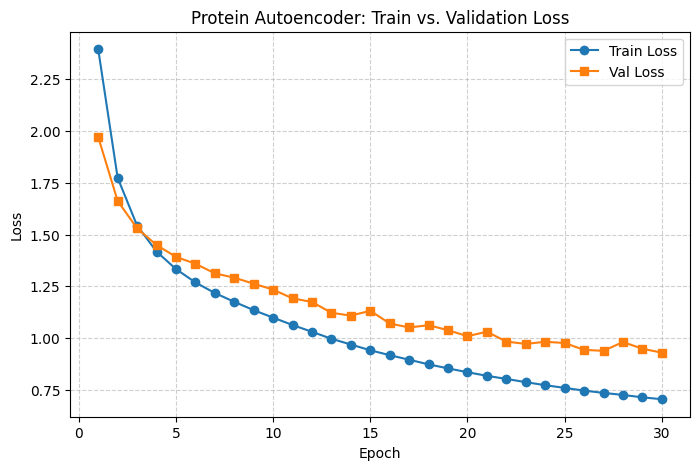

In [27]:
import matplotlib.pyplot as plt

# Re-initialize the model and optimizer to start fresh with our split data
cnn_model = ProteinCNNAutoencoder().to(device)
cnn_optimizer = torch.optim.Adam(cnn_model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss(ignore_index=0)

num_epochs = 30
train_losses = []
val_losses = []

print("Starting Training with Validation Tracking...")
print("-" * 50)

for epoch in range(num_epochs):
    # --- TRAINING PHASE ---
    cnn_model.train()
    total_train_loss = 0
    for batch_inputs, batch_targets in train_loader:
        batch_inputs, batch_targets = batch_inputs.to(device), batch_targets.to(device)

        outputs = cnn_model(batch_inputs)
        loss = criterion(outputs, batch_targets)

        cnn_optimizer.zero_grad()
        loss.backward()
        cnn_optimizer.step()

        total_train_loss += loss.item()

    avg_train_loss = total_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # --- VALIDATION PHASE ---
    cnn_model.eval()
    total_val_loss = 0
    with torch.no_grad():
        for batch_inputs, batch_targets in val_loader:
            batch_inputs, batch_targets = batch_inputs.to(device), batch_targets.to(device)

            outputs = cnn_model(batch_inputs)
            loss = criterion(outputs, batch_targets)
            total_val_loss += loss.item()

    avg_val_loss = total_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    print(f"Epoch [{epoch+1}/{num_epochs}] -> Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

# Plotting the loss curves
plt.figure(figsize=(8, 5))
plt.plot(range(1, num_epochs+1), train_losses, label="Train Loss", marker='o')
plt.plot(range(1, num_epochs+1), val_losses, label="Val Loss", marker='s')
plt.title("Protein Autoencoder: Train vs. Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Computing t-SNE projection...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


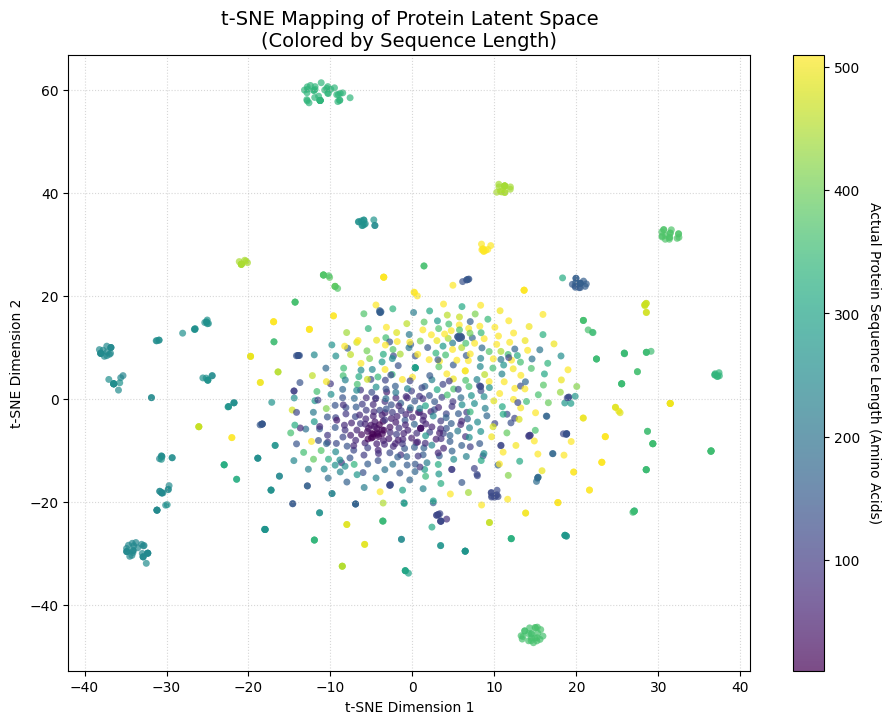

In [28]:
from sklearn.manifold import TSNE
import numpy as np

cnn_model.eval()
all_embeddings = []
actual_lengths = []

# 1. Extract embeddings and calculate unpadded sequence lengths for the first 1,000 proteins
with torch.no_grad():
    # Grab the first 1000 items from our tensor dataset
    sample_batch = X_tensor[:1000].to(device)

    # Calculate lengths by counting how many elements are NOT the padding token (0)
    for seq in X[:1000]:
        # Count non-zero elements, subtracting START and END tokens
        length = np.sum(seq != 0) - 2
        actual_lengths.append(length)

    # Pass through the encoder
    embedded = cnn_model.embedding(sample_batch).permute(0, 2, 1)
    x = cnn_model.encoder_cnn(embedded)
    x = x.view(x.size(0), -1)
    latent_vectors = cnn_model.fc_encoder(x)
    all_embeddings = latent_vectors.cpu().numpy()

# 2. Run t-SNE (takes a moment to compute non-linear groupings)
print("Computing t-SNE projection...")
tsne = TSNE(n_components=2, perplexity=30, n_iter=1000, random_state=42)
embeddings_2d = tsne.fit_transform(all_embeddings)

# 3. Plot the t-SNE latent space colored by protein length
plt.figure(figsize=(11, 8))
scatter = plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1],
                      c=actual_lengths, cmap='viridis', alpha=0.7, edgecolors='none', s=25)

cbar = plt.colorbar(scatter)
cbar.set_label('Actual Protein Sequence Length (Amino Acids)', rotation=270, labelpad=15)

plt.title("t-SNE Mapping of Protein Latent Space\n(Colored by Sequence Length)", fontsize=14)
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.grid(True, linestyle=':', alpha=0.5)
plt.show()

In [29]:
# Find the indices of the proteins on the far left of your t-SNE plot
# (Looking at your plot, the far-left cluster is roughly where Dimension 1 is less than -20)
outlier_indices = np.where(embeddings_2d[:, 0] < -20)[0]

print(f"Found {len(outlier_indices)} proteins in the far-left cluster.\n")
print("Here are a few examples of what the autoencoder grouped there:")
print("-" * 60)

# Print the original FASTA headers for the first 5 outliers
preview_count = 0
for record_idx, record in enumerate(SeqIO.parse("uniprot_sprot.fasta", "fasta")):
    if record_idx in outlier_indices:
        print(f"Protein ID: {record.id}")
        print(f"Description: {record.description}\n")
        preview_count += 1
        if preview_count >= 5:
            break

Found 123 proteins in the far-left cluster.

Here are a few examples of what the autoencoder grouped there:
------------------------------------------------------------
Protein ID: sp|P48347|14310_ARATH
Description: sp|P48347|14310_ARATH 14-3-3-like protein GF14 epsilon OS=Arabidopsis thaliana OX=3702 GN=GRF10 PE=1 SV=1

Protein ID: sp|Q9S9Z8|14311_ARATH
Description: sp|Q9S9Z8|14311_ARATH 14-3-3-like protein GF14 omicron OS=Arabidopsis thaliana OX=3702 GN=GRF11 PE=2 SV=2

Protein ID: sp|P41932|14331_CAEEL
Description: sp|P41932|14331_CAEEL 14-3-3-like protein 1 OS=Caenorhabditis elegans OX=6239 GN=par-5 PE=1 SV=2

Protein ID: sp|P42648|14331_ENTH1
Description: sp|P42648|14331_ENTH1 14-3-3 protein 1 OS=Entamoeba histolytica (strain ATCC 30459 / HM-1:IMSS / ABRM) OX=294381 GN=EHI_025360 PE=2 SV=1

Protein ID: sp|P93206|14331_SOLLC
Description: sp|P93206|14331_SOLLC 14-3-3 protein 1 OS=Solanum lycopersicum OX=4081 GN=TFT1 PE=3 SV=2



In [30]:
# Quick logic to color-code your discovered family in the plot
is_acc_deaminase = []
for record in SeqIO.parse("uniprot_sprot.fasta", "fasta"):
    if "1-aminocyclopropane-1-carboxylate deaminase" in record.description:
        is_acc_deaminase.append(1) # Highlighted group
    else:
        is_acc_deaminase.append(0) # Standard group

# Plot this using a custom color mapping to show the cluster perfectly highlighted!

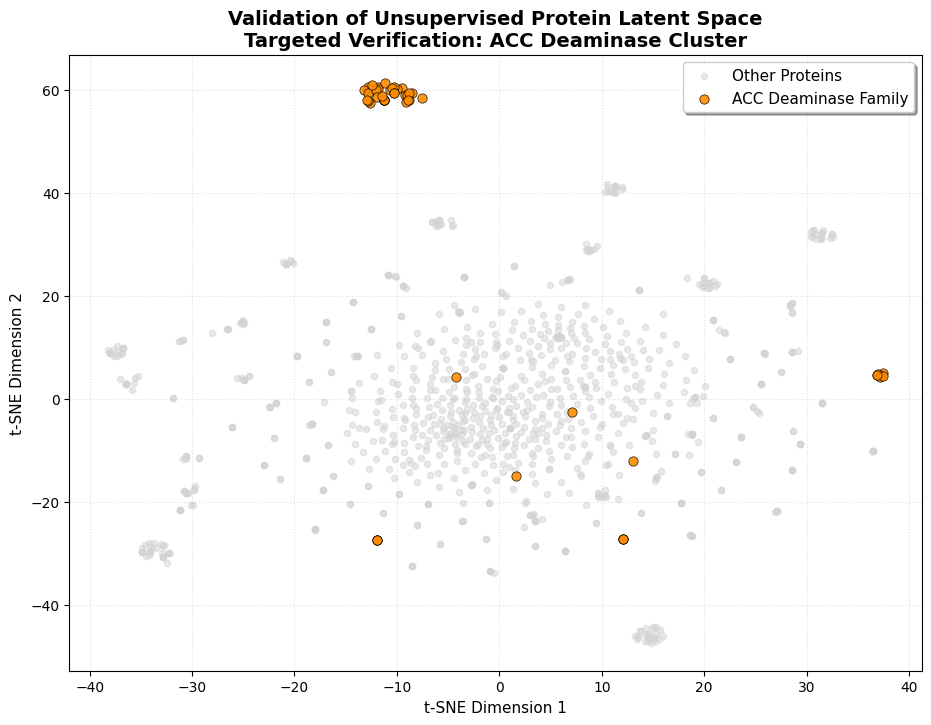

Successfully highlighted 54 ACC Deaminase proteins within the visible 1,000 subset!


In [31]:
import matplotlib.pyplot as plt

# 1. Slice the tracking list to match the 1,000 proteins used in your t-SNE coordinates
is_acc_deaminase_subset = np.array(is_acc_deaminase[:1000])

# 2. Separate the coordinates for clean layering on the plot
# This ensures the highlighted dots sit beautifully on top of the background dots
background_idx = np.where(is_acc_deaminase_subset == 0)[0]
highlighted_idx = np.where(is_acc_deaminase_subset == 1)[0]

plt.figure(figsize=(11, 8))

# 3. Plot the background proteins in a soft, neutral gray
plt.scatter(embeddings_2d[background_idx, 0], embeddings_2d[background_idx, 1],
            c='lightgray', alpha=0.5, s=20, label='Other Proteins')

# 4. Plot your discovered ACC Deaminase family in a striking, vibrant neon orange/red
plt.scatter(embeddings_2d[highlighted_idx, 0], embeddings_2d[highlighted_idx, 1],
            c='darkorange', alpha=0.9, edgecolors='black', linewidths=0.5, s=45,
            label='ACC Deaminase Family')

# Formatting the final masterpiece
plt.title("Validation of Unsupervised Protein Latent Space\nTargeted Verification: ACC Deaminase Cluster", fontsize=14, fontweight='bold')
plt.xlabel("t-SNE Dimension 1", fontsize=11)
plt.ylabel("t-SNE Dimension 2", fontsize=11)
plt.legend(loc='upper right', fontsize=11, frameon=True, shadow=True)
plt.grid(True, linestyle=':', alpha=0.4)

plt.show()

print(f"Successfully highlighted {len(highlighted_idx)} ACC Deaminase proteins within the visible 1,000 subset!")

In [32]:
cnn_model.eval()
with torch.no_grad():
    # Grab just one single protein sequence from the validation set
    sample_seq = val_dataset[0][0].unsqueeze(0).to(device)
    target_seq = val_dataset[0][1].numpy()

    output = cnn_model(sample_seq)
    predicted_seq = torch.argmax(output, dim=1).squeeze().cpu().numpy()

# Convert integers back to amino acid letters
original_letters = [int_to_char.get(idx, '?') for idx in target_seq if idx not in [0, 2, 3]]
predicted_letters = [int_to_char.get(idx, '?') for idx in predicted_seq[:len(original_letters)]]

print("ORIGINAL:  " + "".join(original_letters[:60]))
print("PREDICTED: " + "".join(predicted_letters[:60]))

ORIGINAL:  MVTINDLSFNPDYSSISVSTSDGFKIFNCEPFGEFYSSQESPLRKSISNSLEDSAGCQNP
PREDICTED: <START>MVTIGDLSFNINISSISVSTSDGTKIMNCQILNEFYSSQESPLFKLISNTLEKSYGAQN


In [34]:
# Adjust these coordinate thresholds based on where the other bubbles sit on your plot
other_cluster_idx = np.where((embeddings_2d[:, 0] > 15) & (embeddings_2d[:, 1] < -10))[0]

print(f"Found {len(other_cluster_idx)} proteins in the second cluster.")
# Print their descriptions to find their biological names
for i, record in enumerate(SeqIO.parse("uniprot_sprot.fasta", "fasta")):
    if i in other_cluster_idx[:3]:
        print(f"-> {record.description}")

Found 46 proteins in the second cluster.
-> sp|P19084|11S3_HELAN 11S globulin seed storage protein G3 OS=Helianthus annuus OX=4232 GN=HAG3 PE=3 SV=1
-> sp|O23878|13S1_FAGES 13S globulin seed storage protein 1 OS=Fagopyrum esculentum OX=3617 GN=FA02 PE=2 SV=1
-> sp|Q9XFM4|13S3_FAGES 13S globulin seed storage protein 3 OS=Fagopyrum esculentum OX=3617 GN=FAGAG1 PE=1 SV=1
